# Route alignment — the working behind the report

Two dashcam traversals of one loop route, two side-facing fisheye cameras, 10 FPS.
The report (`report/route_alignment_report.pdf`) states results; this
notebook shows where each of them comes from, in the report's own order.

**How to read it.** Each section calls the module in `scripts/` that produced the
number, or reads the evidence artifact under `outputs/` that the report cites, and
where both exist it checks that they agree. The code stays in the scripts: the
notebook imports and calls it rather than re-typing it, so what runs here is what
ran for the report.

**What it never does.** No sealed label set is scored again with different
parameters. Every held-out figure is read from its single scoring pass; the live
computations are re-derivations from the sealed labels and the frozen mapping
files, and they must reproduce the shipped figure.

**What needs the raw recordings.** The HEVC files are not in the submission
bundle. The cells that parse or decode them say so at the top and skip cleanly
when the files are absent; their outputs are kept as executed.

| Section | Report | What runs |
|---|---|---|
| 1 | Characterising the recordings | bitstream scan, integrity gates, sidecar timing, cameras, reliability mask, route topology |
| 2 | Method | frozen parameters verified against live code, resolution study, mapping contract, evaluation ordering |
| 3 | Results and two protocol defects | tolerance curve recomputed, label semantics, targeted sets, convention constant, abstention, CAM5 mechanism, label-free signals, exposure |
| 4 | Downstream policy | policy table, quality flags, slope gate, loop closure, posterior, the strict single-frame table |

In [1]:
import csv
import json
import sys
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image as ShowImage, display

ROOT = Path.cwd() if (Path.cwd() / "scripts").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "scripts"))
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

RUNS, CAMERAS = ("runA", "runB"), ("cam0", "cam5")


def load(relative):
    return json.loads((ROOT / relative).read_text())


def available(*relative):
    missing = [r for r in relative if not (ROOT / r).exists()]
    if missing:
        print("skipped here: not in this bundle ->", ", ".join(missing))
    return not missing


def wilson(interval):
    return f"{interval[0]:.2f}-{interval[1]:.2f}"


import frame_service

RAW = all(frame_service.source_available(run, camera) for run in RUNS for camera in CAMERAS)
print("repository root:", ROOT.name)
print("raw recordings present:", RAW)

repository root: route-alignment
raw recordings present: True


## 1. Characterising the recordings

### 1.1 Picture counts, rasters and picture order, read from the bitstream

The report's inventory table comes from a purpose-written HEVC Annex-B scanner
(`scripts/hevc_bitstream.py`) that parses NAL units, the sequence parameter
set and every slice header, and reconstructs picture order count independently of
libavcodec. The table below is the shipped artifact; when the recordings are
present the scanner runs again and must agree with it exactly.

In [2]:
inventory = pd.read_csv(ROOT / "outputs/task1/task1_bitstream_summary.csv")
display(inventory[["run", "camera", "bitstream_picture_count", "coded_raster", "display_raster",
                   "slice_type_I", "slice_type_P", "slice_type_B", "reordered_picture_fraction"]])

# needs the raw recordings
if RAW:
    import hevc_bitstream

    expected = inventory.set_index(["run", "camera"])
    for run in RUNS:
        for camera in CAMERAS:
            scan = hevc_bitstream.scan(frame_service.source_path(run, camera))
            scan.verify_display_order_is_permutation()
            pictures = len(scan.pictures)
            reordered = scan.reordered_picture_count
            assert pictures == expected.loc[(run, camera), "bitstream_picture_count"]
            assert abs(reordered / pictures - expected.loc[(run, camera), "reordered_picture_fraction"]) < 1e-6
            first = [p.picture_order_count for p in scan.pictures[:9]]
            print(f"{run}/{camera}: {pictures} pictures, {reordered} reordered ({reordered / pictures:.1%}), "
                  f"decode-order POC {first}, SEI {scan.sei_payload_counts}, "
                  f"file size mod 4096 = {scan.file_size % 4096}")
    print("live scan agrees with the shipped inventory on all four files")

,run,camera,bitstream_picture_count,coded_raster,display_raster,slice_type_I,slice_type_P,slice_type_B,reordered_picture_fraction
0,runA,cam0,2674,1440x1088,1440x1080,11,674,1989,0.743829
1,runA,cam5,2674,1440x1088,1440x1080,11,674,1989,0.743829
2,runB,cam0,2622,1440x1088,1440x1080,11,661,1950,0.743707
3,runB,cam5,2615,1440x1088,1440x1080,11,659,1945,0.744168


runA/cam0: 2674 pictures, 1989 reordered (74.4%), decode-order POC [0, 4, 2, 1, 3, 8, 6, 5, 7], SEI {'pic_timing': 2674}, file size mod 4096 = 0
runA/cam5: 2674 pictures, 1989 reordered (74.4%), decode-order POC [0, 4, 2, 1, 3, 8, 6, 5, 7], SEI {'pic_timing': 2674}, file size mod 4096 = 0


runB/cam0: 2622 pictures, 1950 reordered (74.4%), decode-order POC [0, 4, 2, 1, 3, 8, 6, 5, 7], SEI {'pic_timing': 2622}, file size mod 4096 = 0


runB/cam5: 2615 pictures, 1946 reordered (74.4%), decode-order POC [0, 4, 2, 1, 3, 8, 6, 5, 7], SEI {'pic_timing': 2615}, file size mod 4096 = 0
live scan agrees with the shipped inventory on all four files


The decode-order picture-order-count sequence 0, 4, 2, 1, 3, 8, 6, 5, 7 is the
four-frame B-pyramid: a tool that enumerates packets and calls the n-th one
"frame n" scrambles the sequence locally, by the same magnitude as the alignment
error being measured. The only SEI present is `pic_timing`; there is no GPS, no
odometry and no calibration anywhere in the four files or the two sidecars.

### 1.2 Integrity gates

`frame_service.verify()` runs every gate over all four recordings: published
checksum, decoded count against the bitstream count, display order a clean
permutation, raster, sidecar monotonicity, parked-tail bound, and the shared
sidecar. Two gates are **waived, not passed**; the waiver is a recorded exception,
not a silent pass, because a finding that cannot fail a build is a finding that
gets forgotten.

In [3]:
# needs the raw recordings (decodes all four files; a few minutes)
if RAW:
    results = frame_service.verify()
    width = max(len(item.gate) for item in results)
    for item in results:
        marker = {"pass": "ok  ", "waived": "WAIV", "FAIL": "FAIL"}[item.status]
        print(f"[{marker}] {item.gate:<{width}}  {item.subject:<11} {item.detail}")
    waived = sum(1 for item in results if item.waived)
    failed = sum(1 for item in results if item.status == "FAIL")
    print(f"\n{len(results)} gates: {len(results) - waived - failed} passed, {waived} waived, {failed} failed")
else:
    waivers = load("outputs/task1/integrity_waivers.json")
    print(json.dumps(waivers, indent=2)[:1500])

[ok  ] run_a_parked_tail_matches_route_bound         runA/cam0   measured onset 2619 vs bound 2616 (tolerance 8)
[ok  ] run_a_parked_tail_matches_route_bound         runA/cam5   measured onset 2617 vs bound 2616 (tolerance 8)
[ok  ] source_checksum_matches_manifest              runA/cam0   sha256 32d3d8c2ee9c vs published 32d3d8c2ee9c
[ok  ] decoded_count_equals_bitstream_picture_count  runA/cam0   decoder 2674 vs bitstream 2674
[ok  ] display_order_is_permutation                  runA/cam0   1989 of 2674 pictures reordered (74.4%)
[ok  ] display_raster_is_1440x1080                   runA/cam0   coded 1440x1088, display 1440x1080, 8 luma rows cropped
[ok  ] source_checksum_matches_manifest              runA/cam5   sha256 2bc77eacd508 vs published 2bc77eacd508
[ok  ] decoded_count_equals_bitstream_picture_count  runA/cam5   decoder 2674 vs bitstream 2674
[ok  ] display_order_is_permutation                  runA/cam5   1989 of 2674 pictures reordered (74.4%)
[ok  ] display_raster_is_1440

### 1.3 Timing: what the sidecars can and cannot say

Each run ships one integer-nanosecond timestamp log. Within a run the two
cameras' logs are byte-identical, yet the two cameras decode to different frame
counts (Run B: 2,622 and 2,615 against one 2,663-row log), so a sidecar row is a
capture-log event, not a decoded frame, and no per-frame capture time is
published. Cadence is measured from the log, not read from the stream's
declaration (which contradicts itself: `r_frame_rate` 10/1, `avg_frame_rate` 25/1).

In [4]:
timing = pd.read_csv(ROOT / "outputs/task1/task1_timing_summary.csv")
display(timing[["run", "timestamp_records", "strictly_increasing", "sidecar_schedules_identical", "start_utc",
                "timestamp_log_span_s", "mean_capture_event_cadence_hz", "interval_median_ms", "interval_max_ms"]])

# needs the raw sidecars
if RAW:
    counts = inventory.set_index(["run", "camera"])["bitstream_picture_count"]
    for run in RUNS:
        stamps = {camera: frame_service.load_timestamps(frame_service.sidecar_path(run, camera)) for camera in CAMERAS}
        t = stamps["cam0"]
        span = (t[-1] - t[0]) / 1e9
        start = datetime.fromtimestamp(t[0] / 1e9, tz=timezone.utc)
        print(f"{run}: {len(t)} rows from {start:%Y-%m-%d %H:%M:%S} UTC, span {span:.3f} s, "
              f"cadence {(len(t) - 1) / span:.4f} Hz, strictly increasing {bool(np.all(np.diff(t) > 0))}, "
              f"cam0 and cam5 logs identical {np.array_equal(stamps['cam0'], stamps['cam5'])}, "
              f"decoded frames cam0 {counts[(run, 'cam0')]} / cam5 {counts[(run, 'cam5')]}")

,run,timestamp_records,strictly_increasing,sidecar_schedules_identical,start_utc,timestamp_log_span_s,mean_capture_event_cadence_hz,interval_median_ms,interval_max_ms
0,runA,2695,True,True,2025-02-28 06:24:09.579559971+00:00,269.594502,9.992785,99.946811,300.823183
1,runB,2663,True,True,2024-04-13 09:12:41.984952117+00:00,266.492267,9.989033,100.016515,396.886524


runA: 2695 rows from 2025-02-28 06:24:09 UTC, span 269.595 s, cadence 9.9928 Hz, strictly increasing True, cam0 and cam5 logs identical True, decoded frames cam0 2674 / cam5 2674
runB: 2663 rows from 2024-04-13 09:12:41 UTC, span 266.492 s, cadence 9.9890 Hz, strictly increasing True, cam0 and cam5 logs identical True, decoded frames cam0 2622 / cam5 2615


### 1.4 Declared against measured

Every figure in the Task 1 inventory carries its provenance class. The colour
finding belongs here: only `color_range=tv` is signalled, so the decoder's matrix
choice depends on frame height, and pinning it changes 3.17% of decoded bytes.
The canonical decode therefore pins BT.709 and every cache key carries source
hash, raster and colour id.

In [5]:
provenance = pd.read_csv(ROOT / "outputs/task1/task1_provenance.csv")
with pd.option_context("display.max_colwidth", 110):
    display(provenance)

,figure,classification,source_or_method,interpretation
0,File size,Measured,Filesystem byte count (Path.stat),Also converted to MiB using 2^20 bytes
1,"Codec, visible/coded raster, pixel format",Tool-reported,FFprobe stream fields,Visible raster is 1440x1080; coded raster is 1440x1088 before the signalled crop; neither is an image-arra...
2,Nominal frame rate,Tool-reported,FFprobe r_frame_rate,10 FPS; metadata-versus-inference origin was not independently established
3,FFprobe avg_frame_rate,Tool-reported,FFprobe avg_frame_rate,25 FPS; not used as achieved cadence because the raw streams have no usable PTS/DTS
4,FFprobe frame count,Measured scan,ffprobe -count_frames,Cross-check only; not the Task 2 frame identity source
5,Decoded image count and RGB shape,Measured decode,ffmpeg version 8.1.2 Copyright (c) 2000-2026 the FFmpeg developers; RGB24 image pass,Defines Task 2 display-order image ordinals and checks every emitted array shape
6,Packet count and PTS/DTS presence,Measured scan,ffprobe packet scan,Packet count is sanity-only and is not another frame-count measurement
7,"Timestamp rows, start, and end",Measured,Complete sidecar text contents,Run-level capture-log evidence; rows are not assigned to decoded images
8,"Log span, cadence, interval statistics",Derived,Integer-nanosecond timestamp differences,"Describes capture events in the sidecars, not exact decoded-video cadence"
9,Cross-camera sidecar equality,Measured comparison,Element-wise array equality,Does not establish decoded-frame-index synchronization


### 1.5 What the cameras actually are

CAM0 faces left and CAM5 right; both are wide fisheye with heavy vignetting. The
scene sweeps laterally, so appearance depends on lane position far more than on a
forward camera. Run B is darker and rain sits on its lens, static for the whole
recording. Two measurements set the difficulty: the sweep rate (RootSIFT median
|dx| between consecutive frames at the geometry raster) and the exposure statistics.

In [6]:
if available("outputs/task2_motion_bayes/sweep_rate_summary.json"):
    sweep = load("outputs/task2_motion_bayes/sweep_rate_summary.json")
    display(pd.DataFrame(sweep["streams"]).T[["frames", "median_px_per_frame", "p10", "p90", "fraction_below_2px"]])

quality = load("outputs/task3/frame_quality_flags.json")
print(quality["thresholds"]["rule"])
display(pd.DataFrame(quality["streams"]).T[["frames", "too_dark", "too_dark_fraction", "mean_luma_median",
                                            "mean_luma_min", "longest_dark_stretch"]])

,frames,median_px_per_frame,p10,p90,fraction_below_2px
runA_cam0,2674.0,23.0,1.0,46.0,0.1017
runA_cam5,2674.0,18.0,0.0,35.0,0.1559
runB_cam0,2622.0,8.0,1.0,25.0,0.1037
runB_cam5,2615.0,10.0,1.0,23.0,0.1476


too_dark iff mean_luma < 12 or p99_luma < 40


,frames,too_dark,too_dark_fraction,mean_luma_median,mean_luma_min,longest_dark_stretch
runA_cam0,2674,48,0.018,61.415,13.058,21
runA_cam5,2674,0,0.0,83.229,13.387,0
runB_cam0,2622,304,0.1159,26.921,3.538,177
runB_cam5,2615,136,0.052,34.749,6.063,72


**The reliability mask, measured rather than predicted.** Content attached to the
camera does not move when the vehicle does. The statistic

$$\text{staticness} = \frac{|\nabla(\text{temporal median})|}{\text{temporal std} + 1}$$

is close to scale-free, which matters because Run B is 2.2× darker and half as
sharp, so a fixed quantile would mask the same fraction of both runs and say
nothing. The same rule finds the wing mirror and the vignette in the dry run and
grows the droplets in the wet one; no trained model is involved
(`scripts/build_reliability_masks.py`).

mask version a17e88c45245; learned components: none; this mask uses no trained model


,run,camera,camera_attached,never_bright,excluded
0,runA,cam0,5.34%,1.76%,7.15%
1,runA,cam5,1.23%,0.24%,1.50%
2,runB,cam0,4.37%,8.55%,12.99%
3,runB,cam5,9.92%,3.27%,13.43%


runA CAM0: red = camera-attached, blue = optically dead


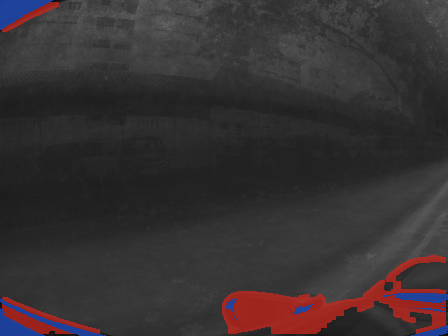

runB CAM0: red = camera-attached, blue = optically dead


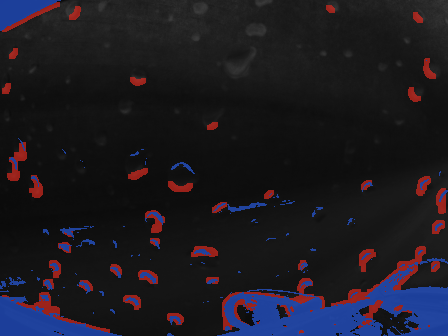

In [7]:
masks = load("outputs/task2_masks/reliability_mask_summary.json")
print(f"mask version {masks['mask_version']}; learned components: {masks['learned_components']}")
rows = []
for key, stats in masks["streams"].items():
    run, camera = key.split("_")
    rows.append({"run": run, "camera": camera,
                 "camera_attached": f"{stats['camera_attached_fraction']:.2%}",
                 "never_bright": f"{stats['never_bright_fraction']:.2%}",
                 "excluded": f"{stats['exclusion_fraction']:.2%}"})
display(pd.DataFrame(rows))

if available("outputs/task2_masks/runA_cam0_mask_overlay.png", "outputs/task2_masks/runB_cam0_mask_overlay.png"):
    for run in RUNS:
        print(f"{run} CAM0: red = camera-attached, blue = optically dead")
        display(ShowImage(filename=str(ROOT / f"outputs/task2_masks/{run}_cam0_mask_overlay.png"), width=520))

### 1.6 Route topology: a loop that also aliases internally

Retrieval over the matcher's own frozen descriptors finds a strong tail-to-head
revisit in all four sequences, so the route is a loop and its endpoints alias.
Interior look-alike pairs far apart along the route are counted too; CAM5 has
about 2.4× CAM0's density of them. Both facts shape the method: no wrap and no
interpolation across the seam, and a global rather than a banded search.

Loop structure and internal aliasing of the route, read from the frozen DINOv2-S descriptor cache the matcher itself uses. 

cam0 runA: tail frame 2604 revisits head frame 180 at cosine 0.9814 (route start 180; median tail-head cosine 0.7273)
cam0 runB: tail frame 2534 revisits head frame 134 at cosine 0.9376 (route start 114; median tail-head cosine 0.7221)
cam0 Run A interior aliasing: 99,721 of 2,745,996 pairs at least 150 frames apart exceed cosine 0.85 (3.6%)

cam5 runA: tail frame 2602 revisits head frame 180 at cosine 0.9749 (route start 180; median tail-head cosine 0.8207)
cam5 runB: tail frame 2603 revisits head frame 122 at cosine 0.9436 (route start 114; median tail-head cosine 0.7937)
cam5 Run A interior aliasing: 234,024 of 2,745,996 pairs at least 150 frames apart exceed cosine 0.85 (8.5%)

CAM5 / CAM0 non-local look-alike pairs: 234,024 / 99,721 = 2.35x  (by cosine threshold: {'0.8': 1.65, '0.85': 2.35, '0.9': 1.58})


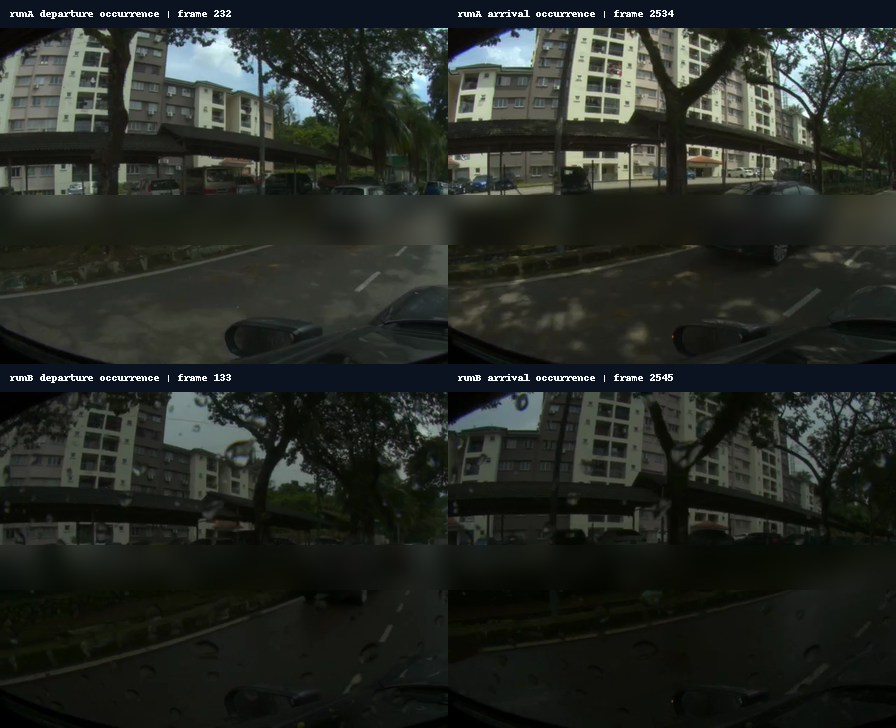

In [8]:
topology = load("outputs/task1/route_topology.json")
print(topology["what_this_measures"], "\n")
for camera in CAMERAS:
    entry = topology["cameras"][camera]
    for run, stats in entry["runs"].items():
        revisit = stats["revisit"]
        print(f"{camera} {run}: tail frame {revisit['tail_frame']} revisits head frame {revisit['head_frame']} "
              f"at cosine {revisit['best_cosine']} (route start {stats['route_start']}; median tail-head cosine {revisit['median_cosine']})")
    alias = entry["runA_aliasing"]
    print(f"{camera} Run A interior aliasing: {alias['non_local_pairs']:,} of {alias['eligible_pairs']:,} pairs at least "
          f"{alias['separation_frames']} frames apart exceed cosine {alias['cosine_threshold']} ({alias['non_local_fraction']:.1%})\n")
ratio = topology["aliasing_ratio"]
print(f"CAM5 / CAM0 non-local look-alike pairs: {ratio['cam5_pairs']:,} / {ratio['cam0_pairs']:,} = "
      f"{ratio['ratio_cam5_over_cam0']}x  (by cosine threshold: {ratio['by_threshold']})")
display(ShowImage(filename=str(ROOT / "outputs/task1/cam0_loop_closure_comparison.png"), width=760))

## 2. Method

### 2.1 The stages, and the frozen parameters verified against live code

Canonical decoded image → reliability mask → frozen DINOv2-S masked descriptor →
full-route coarse similarity → monotonic path with a slope prior → full-cadence
refinement → local RootSIFT/RANSAC → accept or abstain
(`scripts/build_task2_unified.py`). Each stage answers an observed failure of the
simpler one: linear progress drifts 12.4 s, nearest-neighbour retrieval confuses
the repeated awnings and corridors, and forced dense output cannot be right where
nothing corresponds.

The method was frozen before any blind label was imported. The freeze file hashes
every parameter, and the verifier below refuses if any live constant has drifted.

In [9]:
freeze = load("outputs/task2_evaluation/method_freeze_v2.json")
print(freeze["status"], "at", freeze["frozen_at_utc"])
print("training performed:", freeze["training_performed"][:120])
frozen = {key: value for key, value in freeze["frozen_parameters"].items() if not isinstance(value, dict)}
display(pd.Series(frozen, name="frozen value").to_frame())

import freeze_method_v2
import freeze_method_v3

freeze_method_v2.verify()
freeze_method_v3.verify(quiet=True)
freeze_method_v3.verify(quiet=True, set_name="blind_v3b")
print("all three freezes verify against the live code and the judged artifacts")

frozen_before_blind_v2_labels_were_imported at 2026-09-01T15:41:34.222655+00:00
training performed: none. DINOv2 is frozen pretrained; the mask, path, sequence gate and geometry verifier are deterministic algorithms. Com


,frozen value
pipeline_version,unified-v1
descriptor_version,dinov2s-masked-v1
mask_version,a17e88c45245
colour_id,bt709-tv2pc
descriptor_raster,"[448, 336]"
geometry_raster,"[896, 672]"
coarse_stride,4
dtw_steps,"[[1, 1], [1, 2], [2, 1], [1, 3], [3, 1], [2, 2]]"
slope_penalty_weight,0.035
skip_penalty_weight,0.008


Method freeze e3b115533f5d verified against live code
  frozen at 2026-09-01T15:41:34.222655+00:00
  23 parameter groups match
all three freezes verify against the live code and the judged artifacts


### 2.2 The geometry raster was chosen by measurement

RootSIFT/RANSAC runs at 896×672, not native. The controlled study
(`scripts/run_geometry_resolution_study.py`, on the original calibration labels
reclassified as development data) shows passing peaks at 896×672 and *falls* at
native: fine foliage texture inflates the raw match count while the inlier ratio
drops. Keypoint count alone would have chosen wrong.

In [10]:
resolution = pd.read_csv(ROOT / "outputs/task2_unified/resolution_study/geometry_resolution_study.csv")
display(resolution)
if available("outputs/task2_unified/resolution_study/geometry_resolution_study.json"):
    study = load("outputs/task2_unified/resolution_study/geometry_resolution_study.json")
    print("selected:", study["selected_resolution"], "|", study["selection_rule"])
    print(study["finding"])

,camera_id,width,height,pairs,median_keypoints_runA,median_keypoints_runB,median_matches,median_inliers,mean_inlier_ratio,passed_distributed_support,seconds_per_pair
0,cam0,448,336,6,720,683,22,18,0.8108,2,0.416
1,cam0,640,480,6,1513,1461,31,21,0.6957,4,0.822
2,cam0,896,672,6,3083,2912,48,29,0.6052,6,1.726
3,cam0,1440,1080,6,9053,7323,85,27,0.3859,4,5.627
4,cam5,448,336,6,612,519,12,10,0.7076,1,0.351
5,cam5,640,480,6,1259,1015,21,11,0.6220,1,0.727
6,cam5,896,672,6,2607,1952,40,16,0.4629,5,1.390
7,cam5,1440,1080,6,7333,4649,86,23,0.3283,2,4.230


selected: {'cam0': '896x672', 'cam5': '896x672'} | maximum passing pairs, ties broken by lower cost per pair
Passing rate peaks at 896x672 and falls again at native resolution, where fine foliage texture inflates the raw match count while the inlier ratio collapses. Keypoint count alone would have chosen wrong.


### 2.3 The mapping contract, and what the shipped files contain

Every Run A ordinal gets one row; `runB_frame` may be empty but `status` may not;
the mapping is monotonic. `confidence` is an ordinal rank, not a probability, and
its 0.50 tier never occurs. The mapping is many-to-one where Run B is slower,
which is expected and fatal to a consumer keying on `runB_frame`.

In [11]:
import build_task2_unified

for camera in CAMERAS:
    build_task2_unified.validate_mapping(ROOT / f"outputs/task2_unified/{camera}/frame_mapping_unified.csv", 2674)

rows = []
for camera in CAMERAS:
    manifest = load(f"outputs/task2_unified/{camera}/unified_manifest.json")
    mapping = pd.read_csv(ROOT / f"outputs/task2_unified/{camera}/frame_mapping_unified.csv")
    mapped = mapping.dropna(subset=["runB_frame"])
    multiplicity = mapped["runB_frame"].value_counts()
    rows.append({"camera": camera, "rows": manifest["rows"], "mapped": manifest["mapped"],
                 "coverage": f"{manifest['coverage']:.3f}", **manifest["status_counts"],
                 "confidence tiers": dict(mapping["confidence"].round(2).value_counts().sort_index()),
                 "rows sharing a partner": f"{(multiplicity[mapped['runB_frame']].values > 1).mean():.0%}",
                 "max multiplicity": int(multiplicity.max())})
with pd.option_context("display.max_colwidth", 80):
    display(pd.DataFrame(rows).set_index("camera").T)

frame_mapping_unified.csv: 2674 rows, 2401 mapped (89.79%), monotonic, all rows typed
frame_mapping_unified.csv: 2674 rows, 2183 mapped (81.64%), monotonic, all rows typed


camera,cam0,cam5
rows,2674,2674
mapped,2401,2183
coverage,0.898,0.816
idle_segment,238,238
loop_ambiguous,3,4
geometry_failed,29,56
accepted_sequence_supported,35,294
accepted_strong,2366,1881
out_of_route,3,3
confidence tiers,"{0.0: 273, 0.67: 35, 1.0: 2366}","{0.0: 491, 0.33: 8, 0.67: 294, 1.0: 1881}"


### 2.4 Evaluation design: the ordering is on record

Prediction-blind labels: the page showed the query frame and a scrubbable Run B
filmstrip, nothing else. For every set the query set was exported, the method
frozen, the labels sealed, and the set scored once, and each file cites the hash
of the one before it. That records *ordering*, not custody; the report says so.

In [12]:
seal_v2 = load("outputs/task2_evaluation/blind_v2/label_seal.json")
metrics_v2 = load("outputs/task2_evaluation/blind_v2/blind_v2_metrics.json")
v3 = load("outputs/task2_evaluation/blind_v3/blind_v3_results.json")
v3b = load("outputs/task2_evaluation/blind_v3b/blind_v3b_results.json")

timeline = pd.DataFrame([
    {"set": "blind_v2", "labels": seal_v2["rows"],
     "query set exported": seal_v2["query_set_exported_at_utc_recovered_from_frame_mtimes"],
     "method frozen": metrics_v2["method_frozen_at_utc"], "labels sealed": seal_v2["sealed_at_utc"],
     "scored": metrics_v2["evaluated_at_utc"]},
    {"set": "blind_v3", "labels": v3["labels"], "query set exported": v3["query_set_exported_at_utc"],
     "method frozen": v3["method_frozen_at_utc"], "labels sealed": v3["label_sealed_at_utc"],
     "scored": v3["evaluated_at_utc"]},
    {"set": "blind_v3b", "labels": v3b["labels"], "query set exported": v3b["query_set_exported_at_utc"],
     "method frozen": v3b["method_frozen_at_utc"], "labels sealed": v3b["label_sealed_at_utc"],
     "scored": v3b["evaluated_at_utc"]},
]).set_index("set")
for column in timeline.columns[1:]:
    timeline[column] = pd.to_datetime(timeline[column]).dt.strftime("%m-%d %H:%M:%S")
display(timeline)

stages = ["query set exported", "method frozen", "labels sealed", "scored"]
for name, row in timeline.iterrows():
    assert list(row[stages]) == sorted(row[stages]), name
print("every set: exported < frozen < sealed < scored")
print("\nblindness checks performed on v2:")
for check in seal_v2["blindness_checks_performed"]:
    print(" -", check)
print("\nseal trust model:", seal_v2["trust_model"])

,labels,query set exported,method frozen,labels sealed,scored
set,,,,,
blind_v2,80,09-01 13:03:06,09-01 15:41:34,09-01 15:52:15,09-01 15:52:23
blind_v3,48,09-02 07:43:09,09-02 07:53:32,09-02 09:14:33,09-02 09:22:15
blind_v3b,24,09-02 09:57:53,09-02 10:03:08,09-02 10:53:30,09-02 11:02:24


every set: exported < frozen < sealed < scored

blindness checks performed on v2:
 - no model-derived columns present
 - every query answered, none left unlabelled
 - Run A frames match the exported query set exactly
 - no_match rows name no Run B frame
 - preferred frame lies inside its acceptable interval

seal trust model: The seal proves these labels existed unchanged before the method freeze that cites this hash. It does not prove the labels were never inspected; that would require third-party custody.


## 3. Results, and two protocol defects

### 3.1 Precision at frame tolerances, recomputed from the sealed labels

The headline reading: the share of accepted match labels whose prediction lies
within ±k frames of the annotator's acceptable interval (distance 0 inside it).
One frame is 0.1 s, about a metre of travel, so ±2 is roughly 2 m, an order of
magnitude tighter than the 25 m or ±10-frames-at-1 FPS tolerances published
place-recognition protocols use. Cameras are never pooled. The cell calls
`evaluate_tolerance_curve.curve()` on the sealed label files and the frozen
mapping files and checks the result against the shipped `tolerance_curve.json`.

In [13]:
import evaluate_tolerance_curve as tol

shipped = load("outputs/task2_evaluation/tolerance_curve.json")
rows, agree = [], True
for set_name, spec in tol.LABEL_SETS.items():
    with (ROOT / spec["labels"]).open(newline="") as handle:
        labels = [r for r in csv.DictReader(handle) if r["label"] == "match"]
    for camera in spec["cameras"]:
        camera_labels = [r for r in labels if r["camera_id"] == camera]
        for method, pattern in spec["methods"].items():
            if not (ROOT / pattern.format(camera=camera)).is_file():
                continue
            result = tol.curve(camera_labels, tol.load_mapping(pattern, camera))
            reference = shipped["sets"][set_name]["cameras"][camera][method]
            agree &= all(result["within"][str(t)]["fraction"] == reference["within"][str(t)]["fraction"]
                         for t in tol.TOLERANCES)
            rows.append({"set": set_name, "camera": camera, "method": method,
                         "match labels": result["match_labels"], "accepted": result["accepted"],
                         "coverage": f"{result['coverage']:.0%}",
                         **{f"±{t}": (f"{result['within'][str(t)]['fraction']:.1%}"
                                      if result["within"][str(t)]["fraction"] is not None else "-")
                            for t in tol.TOLERANCES}})
display(pd.DataFrame(rows))
print(f"headline tolerance ±{tol.HEADLINE_TOLERANCE}; recomputed curves equal the shipped tolerance_curve.json: {agree}")
print("\n" + shipped["literature_context"])

,set,camera,method,match labels,accepted,coverage,±0,±1,±2,±5,±10
0,blind_v2,cam0,submitted,32,32,100%,71.9%,81.2%,84.4%,90.6%,96.9%
1,blind_v2,cam5,submitted,37,32,86%,37.5%,56.2%,68.8%,90.6%,96.9%
2,blind_v3,cam0,submitted,21,21,100%,61.9%,71.4%,81.0%,85.7%,100.0%
3,blind_v3,cam0,slope_variant,21,21,100%,76.2%,81.0%,81.0%,90.5%,100.0%
4,blind_v3,cam0,posterior,21,21,100%,71.4%,85.7%,85.7%,90.5%,100.0%
5,blind_v3b,cam5,submitted,23,21,91%,14.3%,38.1%,71.4%,85.7%,100.0%
6,blind_v3b,cam5,slope_variant,23,21,91%,19.1%,52.4%,81.0%,100.0%,100.0%
7,blind_v3b,cam5,posterior,23,23,100%,17.4%,47.8%,82.6%,95.7%,95.7%


headline tolerance ±2; recomputed curves equal the shipped tolerance_curve.json: True

Published place-recognition protocols count a hit at 25 m (Pitts30k, Tokyo24/7, MSLS, RobotCar) or at +-10 frames at 1 FPS on Nordland; the tightest published Nordland readings use +-2 or +-1 frames at 1 FPS, i.e. +-10-40 m. The +-2-frame headline here is about 2 m. Not the same data; context for the scale of the tolerance only.


### 3.2 A label-semantics correction, made after the fact

The v2 page offered a match or "no usable match", merging two facts: that Run B
has no counterpart here, and that the annotator could not tell. Every such label
meant the second, and that is checkable without any result: queries were drawn
inside the stretch both runs traversed, so a genuine absence was impossible by
construction. Undetermined queries leave the denominator; the correction was made
*after* the results were seen, applied identically to both methods, and both
readings are kept (the strict table in §4.3 carries the uncorrected column).

In [14]:
labels_v2 = pd.read_csv(ROOT / "outputs/task2_evaluation/blind_v2/blind_v2_labels.csv")
route = load("outputs/task2_unified/cam0/unified_manifest.json")["route"]
undetermined = labels_v2[labels_v2["label"] != "match"]
inside = undetermined["runA_frame"].between(route["runA_start"], route["runA_end_exclusive"] - 1)
print(f"{len(undetermined)} of {len(labels_v2)} v2 labels were 'no usable match' "
      f"(cam0 {int((undetermined['camera_id'] == 'cam0').sum())}, cam5 {int((undetermined['camera_id'] == 'cam5').sum())})")
print(f"all of them lie inside the traversed stretch Run A {route['runA_start']}-{route['runA_end_exclusive'] - 1}: {bool(inside.all())}")
print("so none can be a genuine absence; they are undetermined and leave the precision denominator")

11 of 80 v2 labels were 'no usable match' (cam0 8, cam5 3)
all of them lie inside the traversed stretch Run A 180-2615: True
so none can be a genuine absence; they are undetermined and leave the precision denominator


### 3.3 The targeted sets: v3, and the CAM5 redo v3b

With the v2 labels spent, 48 fresh queries were sealed against a freeze naming
the submitted mapping, the slope variant, the posterior and the gates, and scored
once. Half target kinks and dark stretches, half are a uniform *corridor* control;
targeting used the submitted mapping's own structure, so **only the corridor
stratum is an unbiased route-wide rate**.

**The CAM5 half of v3 was withdrawn** for a defect found in the sealed labels
themselves: the viewer displaced Run B by the measured pose offset instead of its
negation, and the annotator's slider corrections correlate with the mapping's
errors. CAM0's offset is zero, so CAM0 stands. CAM5 was re-asked on 24 fresh
queries under its own freeze with the sign fixed and the slider clamped (v3b).

In [15]:
def method_rows(results, set_name):
    rows = []
    for method, entry in results["methods"].items():
        for camera, stats in entry["cameras"].items():
            rows.append({"set": set_name, "method": method, "camera": camera, "held out": entry["held_out"],
                         "match labels": stats["match_labels"], "accepted": stats["accepted"],
                         "correct": stats["correct"], "strict precision": stats["precision"],
                         "wilson 95%": wilson(stats["precision_wilson_95"]),
                         "within ±2": stats["within_two_rate"], "coverage": stats["coverage_of_match_labels"]})
    return rows

display(pd.DataFrame(method_rows(v3, "blind_v3") + method_rows(v3b, "blind_v3b")))

strata = []
for set_name, results, camera in (("blind_v3", v3, "cam0"), ("blind_v3b", v3b, "cam5")):
    for stratum, stats in results["methods"]["submitted_unified"]["strata"][camera].items():
        strata.append({"set": set_name, "camera": camera, "stratum": stratum, "labels": stats["labels"],
                       "match labels": stats["match_labels"], "accepted": stats["accepted"],
                       "correct": stats["correct"], "precision": stats["precision"],
                       "within ±2": stats["within_two_rate"]})
print("submitted mapping by stratum (only 'corridor' is an unbiased route-wide rate):")
display(pd.DataFrame(strata))

,set,method,camera,held out,match labels,accepted,correct,strict precision,wilson 95%,within ±2,coverage
0,blind_v3,submitted_unified,cam0,True,21,21,13,0.6190,0.41-0.79,0.8095,1.0000
1,blind_v3,submitted_unified,cam5,True,23,23,2,0.0870,0.02-0.27,0.2174,1.0000
2,blind_v3,slope_refinement_variant,cam0,True,21,21,16,0.7619,0.55-0.89,0.8095,1.0000
3,blind_v3,slope_refinement_variant,cam5,True,23,23,3,0.1304,0.05-0.32,0.2609,1.0000
4,blind_v3,posterior_model,cam0,True,21,21,15,0.7143,0.50-0.86,0.8571,1.0000
5,blind_v3,posterior_model,cam5,True,23,22,2,0.0909,0.03-0.28,0.4545,0.9565
6,blind_v3,submitted_plus_slope_gate,cam0,True,21,14,10,0.7143,0.45-0.88,0.8571,0.6667
7,blind_v3,submitted_plus_slope_gate,cam5,True,23,12,1,0.0833,0.01-0.35,0.3333,0.5217
8,blind_v3,submitted_plus_dark_gate,cam0,True,21,16,8,0.5000,0.28-0.72,0.7500,0.7619
9,blind_v3,submitted_plus_dark_gate,cam5,True,23,19,2,0.1053,0.03-0.31,0.2632,0.8261


submitted mapping by stratum (only 'corridor' is an unbiased route-wide rate):


,set,camera,stratum,labels,match labels,accepted,correct,precision,within ±2
0,blind_v3,cam0,kink,8,7,7,3,0.4286,0.7143
1,blind_v3,cam0,dark,4,3,3,3,1.0000,1.0000
2,blind_v3,cam0,occlusion,3,2,2,2,1.0000,1.0000
3,blind_v3,cam0,corridor,9,9,9,5,0.5556,0.7778
4,blind_v3b,cam5,kink,5,5,5,1,0.2000,0.4000
5,blind_v3b,cam5,dark,1,1,1,0,0.0000,1.0000
6,blind_v3b,cam5,occlusion,0,0,0,0,NaN,NaN
7,blind_v3b,cam5,corridor,18,17,15,2,0.1333,0.8000


In [16]:
# The tool defect, re-derived from the sealed v3 labels and cases.
cases_v3 = pd.read_csv(ROOT / "outputs/task2_evaluation/blind_v3/blind_v3_cases.csv")
labels_v3 = pd.read_csv(ROOT / "outputs/task2_evaluation/blind_v3/blind_v3_labels.csv")
joined = cases_v3[(cases_v3["method"] == "submitted_unified") & cases_v3["accepted"]
                  & (cases_v3["ground_truth_label"] == "match")].merge(
    labels_v3[["query_id", "pose_dx_px", "pose_dy_px"]], on="query_id")
for camera in CAMERAS:
    subset = joined[joined["camera_id"] == camera]
    if subset["pose_dx_px"].std() == 0:
        print(f"{camera}: slider dx constant at {subset['pose_dx_px'].iloc[0]:+.0f} px on {len(subset)} labels (no offset to correct)")
        continue
    rho = subset["pose_dx_px"].corr(subset["preferred_frame_error"], method="spearman")
    print(f"{camera}: slider dx used on {len(subset)} accepted match labels, median {subset['pose_dx_px'].median():+.0f} px, "
          f"range {subset['pose_dx_px'].min():+.0f}..{subset['pose_dx_px'].max():+.0f}; "
          f"Spearman(slider dx, signed frame error) = {rho:.2f}")
print("\nCAM5's slider absorbed part of the frame error, so its v3 half cannot judge the mapping; see TOOL_DEFECT_cam5.md")
print(f"v3b: sign fixed at source, every row at the exported default, slider clamped; {v3b['labels']} fresh CAM5 queries")

cam0: slider dx constant at +0 px on 21 labels (no offset to correct)


cam5: slider dx used on 23 accepted match labels, median +81 px, range +10..+200; Spearman(slider dx, signed frame error) = 0.45

CAM5's slider absorbed part of the frame error, so its v3 half cannot judge the mapping; see TOOL_DEFECT_cam5.md
v3b: sign fixed at source, every row at the exported default, slider clamped; 24 fresh CAM5 queries


### 3.4 One pre-measured constant explains part of CAM5's residual

The matcher's "same place" is image content; the labels' is a world position.
For a side-facing camera whose pose changed between the runs the two differ by a
constant: the 18.5 px gap at CAM5's sweep rate is −1.79 frames, measured on the
v2 labels **before** v3b was drawn. Applying the rounded −2 to every CAM5
prediction (the submitted file unchanged) is a sensitivity reading on a spent
set, not a held-out number. Two controls bound it: on the mixed-convention v2
labels the same shift is neutral, and on CAM0, whose offset is zero, the sweep
peaks at 0.

In [17]:
sensitivity = load("outputs/task2_evaluation/blind_v3b/convention_shift_sensitivity.json")
block = sensitivity["convention_shift_sensitivity"]["cam5"]
constant = block["constant"]
print(f"constant: {constant['gap_px']} px = {constant['gap_frames_at_median_sweep']} frames, rounded {constant['rounded_frames']}; "
      f"measured on: {constant['measured_on'][:60]}")
print(sensitivity["evidence_status"][:160], "\n")
def shift_table(by_shift):
    frame = pd.DataFrame(by_shift).T.drop(columns=["shift_frames", "signed_interval_error", "signed_interval_counts"], errors="ignore")
    frame["precision_wilson_95"] = frame["precision_wilson_95"].map(wilson)
    return frame

for method, entry in block["methods"].items():
    frame = shift_table(entry["by_shift"])
    frame.index.name = f"{method}: shift (frames)"
    display(frame)
    print(f"  peak at {entry['peak_shift_frames']} frames; peak is the pre-measured constant: {entry['peak_is_the_measured_constant']}\n")

print("controls: the same sweep on two sets the reading was not meant for")
for name, control in sensitivity["control_sweeps"]["sets"].items():
    frame = shift_table(control["by_shift"])
    frame.index.name = f"{name} ({control['role']}): shift"
    display(frame)
    print(f"  peak at {control['peak_shift_frames']}\n")

constant: -18.5 px = -1.79 frames, rounded -2; measured on: the v2 blind labels, before this label set was drawn; see th
A SENSITIVITY READING, NOT A HELD-OUT NUMBER. The set was scored once and those numbers stand unchanged in blind_v3b_results.json. This rescores the same rows u 



,accepted,correct,precision,precision_wilson_95,within_two,within_two_rate,median_interval_distance
submitted_unified: shift (frames),,,,,,,
0,21,3,0.1429,0.05-0.35,15,0.7143,2.0
-1,21,7,0.3333,0.17-0.55,16,0.7619,1.0
-2,21,14,0.6667,0.45-0.83,15,0.7143,0.0
-3,21,12,0.5714,0.37-0.76,17,0.8095,0.0


  peak at -2 frames; peak is the pre-measured constant: True



,accepted,correct,precision,precision_wilson_95,within_two,within_two_rate,median_interval_distance
slope_refinement_variant: shift (frames),,,,,,,
0,21,4,0.1905,0.08-0.40,17,0.8095,1.0
-1,21,9,0.4286,0.24-0.63,18,0.8571,1.0
-2,21,15,0.7143,0.50-0.86,18,0.8571,0.0
-3,21,14,0.6667,0.45-0.83,19,0.9048,0.0


  peak at -2 frames; peak is the pre-measured constant: True



...

  peak at -2 frames; peak is the pre-measured constant: True

controls: the same sweep on two sets the reading was not meant for


,accepted,correct,precision,precision_wilson_95,signed_late_early_inside
blind_v2:cam5 (mixed_convention_set): shift,,,,,
0,32,12,0.375,0.23-0.55,15:5:12
-1,32,11,0.3438,0.20-0.52,11:10:11
-2,32,12,0.375,0.23-0.55,7:13:12
-3,32,8,0.25,0.13-0.42,3:21:8


  peak at 0



,accepted,correct,precision,precision_wilson_95,signed_late_early_inside
blind_v3:cam0 (zero_offset_control): shift,,,,,
0,21,13,0.619,0.41-0.79,4:4:13
-1,21,9,0.4286,0.24-0.63,3:9:9
-2,21,5,0.2381,0.11-0.45,1:15:5
-3,21,2,0.0952,0.03-0.29,1:18:2


  peak at 0



### 3.5 Abstention: what the labels cannot say, and what can

The v2 set held no true no-correspondence case, so it cannot evaluate abstention.
Withholding a stretch of Run B supplies cases by construction: frames whose
partner lay inside the hole have none. The route also supplies one *real*
absence found by looking at frames: an oncoming lorry fills Run B CAM0 for about
30 frames, and both mappings drive straight through it at confidence 1.00. The
strict-geometry re-read shows why: geometry is propagated between sampled checks,
and reserving the top tier for frames actually checked collapses it.

In [18]:
holdout = load("outputs/task2_abstention/abstention_holdout.json")
print(holdout["scope"])
rows = []
for camera, entry in holdout["cameras"].items():
    for width, stats in entry["by_hole_width"].items():
        rows.append({"camera": camera, "hole (frames)": int(width), "trials": stats["trials"],
                     "detected": f"{stats['detection_rate']:.1%}", "false alarm": f"{stats['false_alarm_rate']:.1%}"})
display(pd.DataFrame(rows))

occlusion = load("outputs/task2_abstention/confirmed_occlusion_runB_cam0.json")
unified = occlusion["unified_mapping"]
print(f"\nconfirmed occlusion: Run B CAM0 {occlusion['interval']['start']}-{occlusion['interval']['end']} "
      f"({occlusion['detail'][0]['occluder']}); source: {occlusion['source']}")
print(f"submitted mapping: {unified['rows_mapped_into_interval']} rows (Run A {unified['runA_frames']['first']}-"
      f"{unified['runA_frames']['last']}) mapped into it, status {unified['status_counts']}, confidence min {unified['confidence']['min']}, "
      f"geometry actually checked on {unified['geometry_checked'].get('true', 0)} of them")
posterior = occlusion["posterior_mapping"]
print(f"posterior model: {posterior['rows_mapped_into_interval']} rows, no-correspondence probability at most "
      f"{posterior['posterior_no_correspondence']['max']}")

strict = load("outputs/task2_unified/cam0/unified_manifest_strict_geometry.json")
loose = load("outputs/task2_unified/cam0/unified_manifest.json")
before, after = loose["status_counts"]["accepted_strong"], strict["status_counts"]["accepted_strong"]
print(f"\nCAM0 top tier when geometry must be verified on the frame itself: {before} -> {after} "
      f"({1 - after / before:.0%} of top-tier acceptances were never verified)")

Measures whether the mechanism can notice an absence. It does not estimate how often absences occur on a real route, and it is not a substitute for a held-out label set.


,camera,hole (frames),trials,detected,false alarm
0,cam0,60,3,39.8%,0.7%
1,cam0,150,3,64.2%,0.6%
2,cam0,400,3,83.5%,0.7%
3,cam5,60,3,92.9%,1.9%
4,cam5,150,3,86.5%,2.3%
5,cam5,400,3,78.9%,2.0%



confirmed occlusion: Run B CAM0 240-270 (oncoming box lorry, whole frame); source: visual inspection of decoded frames; not a label
submitted mapping: 30 rows (Run A 327-356) mapped into it, status {'accepted_strong': 30}, confidence min 1.0, geometry actually checked on 2 of them
posterior model: 30 rows, no-correspondence probability at most 0.000207

CAM0 top tier when geometry must be verified on the frame itself: 2366 -> 156 (93% of top-tier acceptances were never verified)


### 3.6 Why CAM5 is weaker: the camera moved, and it is aimed low

At the matcher's own accepted pairs the CAM5 scene sits displaced by a constant
dx/dy along the whole route, and at the annotator's pairs by a larger dx; CAM0 is
0/0 on both. For a side-facing camera there is no vertical parallax, so dy is
pitch, and a yaw offset and a few frames of travel produce the same horizontal
shift (the degeneracy the diagnostic states). CAM5's failure is a localisation
bias, not place confusion: §3.1 shows it inside ±5 frames on 90% of queries.

In [19]:
pose = load("outputs/task2_pose_offset/pose_offset_diagnostic.json")
print("degeneracy:", pose["degeneracy"][:200], "\n")


def px(stat):
    return f"median {stat['median']:+.1f}, 95% {stat.get('bootstrap_95', stat.get('interval_95', '-'))}, MAD {stat.get('mad', '-')}"


rows = []
for camera in CAMERAS:
    entry = pose["cameras"][camera]
    matcher, label = entry["matcher_convention"], entry["label_convention"]
    rows.append({"camera": camera,
                 "matcher pairs": matcher["pairs_measured"],
                 "matcher dx (px)": px(matcher["dx_px"]), "matcher dy (px)": px(matcher["dy_px"]),
                 "dx trend / 1000 frames": matcher["dx_trend_px_per_1000_frames"],
                 "label pairs": label["labels_measured"], "label dx (px)": px(label["dx_px"]),
                 "label dx constant along route": label["constant_along_route"],
                 "convention gap": f"{entry['label_convention_conversion']['gap_px']} px = "
                                   f"{entry['label_convention_conversion']['gap_frames_at_median_sweep']} frames"})
with pd.option_context("display.max_colwidth", 120):
    display(pd.DataFrame(rows).set_index("camera").T)
speed = pose["cameras"]["cam5"]["dense_speed_check"]
print(f"dense-flow speed against RootSIFT sweep on CAM5: ratio {speed['median_ratio_speed_over_rootsift']}, "
      f"Spearman {speed['spearman']} over {speed['pairs']} pairs")

degeneracy: For a side-facing camera a yaw offset and a few frames of travel produce the same horizontal scene shift. dx at matched pairs therefore reports the matcher's convention, not the pose; dy is unconfound 



camera,cam0,cam5
matcher pairs,96,79
matcher dx (px),"median +0.0, 95% [-3.0, 1.0], MAD 7.41","median -37.5, 95% [-44.5, -29.0], MAD 29.65"
matcher dy (px),"median +0.0, 95% [0.0, 1.0], MAD 2.22","median -11.0, 95% [-12.0, -9.0], MAD 5.93"
dx trend / 1000 frames,-0.64,-1.08
label pairs,31,37
label dx (px),"median +0.0, 95% [-2.0, 4.0], MAD 8.9","median -56.0, 95% [-63.0, -44.0], MAD 22.24"
label dx constant along route,True,True
convention gap,0.0 px = 0.0 frames,-18.5 px = -1.79 frames


dense-flow speed against RootSIFT sweep on CAM5: ratio 0.927, Spearman 0.435 over 72 pairs


### 3.7 A label-free signal, dense over the whole route

CAM0 and CAM5 face opposite sides, so their alignments come from disjoint scenes
and fail near-independently. Comparing them is dense over every frame both map
(`scripts/evaluate_task2_consistency.py`). It measures consistency, not
correctness, and it ran *before any label existed*. It also judged the variants
built once the labels were spent: five input-side changes move nothing; one
change to the pooling (an unsupervised VLAD over the same masked tokens) does.
Kinks, one-step jumps the motion model forbids, belong to the refinement stage and
no descriptor change touches them (`scripts/analyze_mapping_kinks.py`).

In [20]:
consistency = load("outputs/task2_consistency/consistency_summary.json")
agreement = consistency["cross_camera_agreement"]
print(consistency["signal_class"])
print(f"frames mapped by both cameras: {agreement['frames_mapped_by_both_cameras']}; "
      f"apparent constant camera offset median {agreement['apparent_camera_offset_frames']['median']} frames (not an error)")
display(pd.Series(agreement["disagreement_about_the_running_offset"], name="disagreement about the running offset").to_frame())
display(pd.DataFrame(agreement["largest_disagreement_regions"]).head(5))

if available("outputs/task2_variants/variant_comparison.json"):
    variants = load("outputs/task2_variants/variant_comparison.json")["variants"]
    rows = []
    for name, entry in variants.items():
        cross = entry["cross_camera"]
        rows.append({"variant": name, "frames both mapped": cross["frames"], "median": cross["median"], "p95": cross["p95"],
                     "over 10": cross["over_10"],
                     **{f"{camera} coverage": entry["cameras"][camera]["coverage"] for camera in CAMERAS},
                     **{f"{camera} closure": entry["cameras"][camera]["endpoint_closure"] for camera in CAMERAS}})
    print("\nvariants judged by the label-free signals (none submitted; the freeze came first):")
    display(pd.DataFrame(rows).set_index("variant"))

label-free dense consistency; never an accuracy claim
frames mapped by both cameras: 2183; apparent constant camera offset median -3.0 frames (not an error)


,disagreement about the running offset
median_absolute,1.000000
p90_absolute,8.000000
p95_absolute,11.000000
max_absolute,23.000000
frames_over_threshold,137.000000
fraction_over_threshold,0.062758
threshold_frames,10.000000


,runA_start,runA_end,frames,peak_disagreement
0,2416,2432,13,23
1,545,560,16,22
2,1068,1110,43,19
3,536,543,8,17
4,907,915,9,16



variants judged by the label-free signals (none submitted; the freeze came first):


,frames both mapped,median,p95,over 10,cam0 coverage,cam5 coverage,cam0 closure,cam5 closure
variant,,,,,,,,
baseline (submitted),2183,1.0,11.0,0.0628,0.8979,0.8164,4/4,0/3
unified grey,2169,1.0,11.0,0.0512,0.9069,0.8111,4/5,0/3
unified parallax,2183,3.0,12.0,0.0788,0.8979,0.8164,1/4,2/3
unified sky,2215,1.0,12.0,0.0619,0.9024,0.8283,4/4,0/3
unified sky+grey,2189,1.0,12.0,0.0713,0.9069,0.8186,4/5,0/3
unified slope,2195,1.0,9.0,0.0328,0.8979,0.8254,2/4,1/3
unified vlad,2389,1.0,8.0,0.0234,0.9024,0.8979,3/4,0/4
posterior,2399,1.0,4.0,0.0133,0.9061,0.9020,2/5,1/5
posterior + speed,2404,1.0,4.0,0.0121,0.9058,0.9043,2/5,1/5


In [21]:
kinks = load("outputs/task2_kinks/mapping_kinks.json")
bound = kinks["physical_bound"]
print(f"physical bound: {bound['rationale'][:140]}...; headline threshold K>={bound['headline_threshold']}")
rows = []
for name in ("submitted_unified", "variant:slope", "bayes_posterior", "variant:grey", "variant:sky"):
    for camera in CAMERAS:
        entry = kinks["mappings"][name]["per_camera"][camera]
        rows.append({"mapping": name, "camera": camera,
                     **{key: value["kinks"] for key, value in entry["kink_counts"].items()},
                     "max one-step increment": entry["increment_distribution"]["max"],
                     "headline kinks by status": entry.get("headline_kinks_by_status", {})})
display(pd.DataFrame(rows))

mechanism = kinks["mechanism"]
print(f"\nmechanism, CAM0 window Run A {mechanism['window_runA']}: coarse path max step "
      f"{mechanism['coarse_path']['max_one_step_increment']}, submitted mapping max step "
      f"{mechanism['submitted_mapping']['max_one_step_increment']}; route-wide refinement residual pinned at "
      f"+{mechanism['refine_radius']} on {mechanism['route_wide_residual']['frames_at_plus_refine_radius']} frames and at "
      f"-{mechanism['refine_radius']} on {mechanism['route_wide_residual']['frames_at_minus_refine_radius']}")
replay = mechanism["structure_replay"]
print(f"structure replay reproduces the submitted mapping on {replay['frames_matching_submitted']}/{replay['frames_replayed']} frames; "
      f"the monotone floor changed the pick on {replay['frames_where_the_monotone_constraint_changed_the_pick']} of them")

physical bound: increment 1 = equal speed; the coarse search may not sustain more than 2x; >= 4 is a 4x ratio in 0.1 s, already outside the model's own prio...; headline threshold K>=6


,mapping,camera,K>=4,K>=6,K>=8,K>=10,max one-step increment,headline kinks by status
0,submitted_unified,cam0,49,27,16,11,17,{'accepted_strong': 27}
1,submitted_unified,cam5,70,25,12,7,19,"{'accepted_strong': 19, 'accepted_sequence_sup..."
2,variant:slope,cam0,0,0,0,0,3,{}
3,variant:slope,cam5,0,0,0,0,3,{}
4,bayes_posterior,cam0,11,1,1,1,10,{'accepted_posterior': 1}
5,bayes_posterior,cam5,16,1,1,0,9,{'accepted_posterior': 1}
6,variant:grey,cam0,51,32,18,10,16,{'accepted_strong': 32}
7,variant:grey,cam5,65,25,12,6,16,"{'accepted_strong': 17, 'accepted_sequence_sup..."
8,variant:sky,cam0,48,27,18,12,17,{'accepted_strong': 27}
9,variant:sky,cam5,70,25,12,7,19,"{'accepted_strong': 17, 'accepted_sequence_sup..."



mechanism, CAM0 window Run A [880, 940]: coarse path max step 3, submitted mapping max step 11; route-wide refinement residual pinned at +8 on 74 frames and at -8 on 45
structure replay reproduces the submitted mapping on 61/61 frames; the monotone floor changed the pick on 27 of them


### 3.8 Under-exposed frames: a systematic, not a random, error

Dark matches dark almost regardless of place. The exposure flag is measured on
every decoded frame (`scripts/build_frame_quality_flags.py`); the cross-reference
with the submitted mapping and with the blind labels shows where that bites.

In [22]:
display(pd.DataFrame(quality["submitted_mapping"]).T[["accepted_rows", "runB_partner_too_dark", "either_side_too_dark",
                                                       "fraction_of_accepted"]])
for camera in CAMERAS:
    dark = quality["blind_labels"][camera]
    print(f"{camera}: {dark['labels_in_dark_regions']} blind labels in dark regions, {dark['determinable']} determinable, "
          f"{dark['correct']} correct, miss distances {dark['miss_distances_frames']}")

,accepted_rows,runB_partner_too_dark,either_side_too_dark,fraction_of_accepted
cam0,2401,273,273,0.1137
cam5,2183,147,147,0.0673


cam0: 5 blind labels in dark regions, 3 determinable, 2 correct, miss distances [14]
cam5: 3 blind labels in dark regions, 3 determinable, 0 correct, miss distances [3, 8, 16]


## 4. Downstream policy for training or testing

### 4.1 What ships against the per-frame schema

`DATA_POLICY.md` gives the rules (split before anything else, group by route,
date, rig and both cameras, never randomise adjacent frames). What ships against
the closed schema is the quality-flag table plus the mapping CSVs' own columns.
The slope gate demotes any top-tier row within 10 Run A frames of a forbidden
one-step jump; it is advisory on CAM5, where it cost precision on the blind set.

In [23]:
display(pd.read_csv(ROOT / "outputs/task3/policy_summary.csv"))
display(pd.read_csv(ROOT / "outputs/task2_keyframes/route_phase_boundaries.csv")[
    ["run", "stationary_start", "stationary_end", "transition_start", "transition_end", "route_start", "confidence"]])

flags = pd.read_csv(ROOT / "outputs/task3/frame_quality_flags.csv")
display(flags.groupby(["run", "camera"])["flag"].value_counts().unstack(fill_value=0))
print("slope-gate rows demoted:", {camera: quality["slope_gate"]["cameras"][camera]["top_tier_rows_demoted"] for camera in CAMERAS})

schema = load("outputs/task3/frame_manifest_schema.json")
fields = schema.get("properties") or schema.get("fields") or schema
print("\nschema field groups:", [key for key in fields][:40])

,run,camera_id,canonical_decoded_images,pre_route_or_transition_excluded,route_region_images,development_representatives,weak_alignment_rows,sparse_anchor_alternative_rows,raw_archive_disposition,default_route_alignment_disposition
0,runA,cam0,2674,180,2494,295,2401.0,1071.0,retain,eligible_after_qc
1,runA,cam5,2674,180,2494,304,2183.0,287.0,retain,eligible_after_qc
2,runB,cam0,2622,114,2508,297,NaN,NaN,retain,eligible_after_qc
3,runB,cam5,2615,114,2501,301,NaN,NaN,retain,eligible_after_qc


,run,stationary_start,stationary_end,transition_start,transition_end,route_start,confidence
0,runA,0,174,175,179,180,high
1,runB,0,110,111,113,114,medium


flag           ok  too_dark
run  camera                
runA cam0    2626        48
     cam5    2674         0
runB cam0    2318       304
     cam5    2479       136

slope-gate rows demoted: {'cam0': 454, 'cam5': 320}

schema field groups: ['manifest_schema_version', 'policy_version', 'frame_id', 'run_id', 'camera_id', 'source_video_filename', 'decoded_frame_index', 'frame_identity', 'decoder_version', 'width', 'height', 'derived_asset', 'run_start_utc', 'run_end_utc', 'capture_timestamp_ns', 'timestamp_linkage_status', 'nominal_fps_tool_reported', 'timestamp_mean_event_cadence_hz', 'route_phase', 'route_phase_method', 'route_location_group_id', 'route_occurrence', 'decode_status', 'resolution_status', 'quality_flags', 'quality_metric_version', 'semantic_mask_model', 'dynamic_mask_fraction', 'temporal_cluster_id', 'temporal_cluster_size', 'is_temporal_representative', 'sample_weight', 'split', 'split_group_id', 'split_assignment_version', 'leakage_buffer_status', 'paired_camera_group_id', 'partner_run_id', 'partner_camera_id', 'partner_frame_index']


### 4.2 What the loop constrains, without any labels; and the posterior model

Two Run A frames that are the same place on the way out and the way back must map
to two Run B frames that are also the same place (endpoint closure), and
cumulative image motion is a monotone route coordinate a correct mapping should
carry across (path closure). The posterior formulation (a hidden Markov model over
Run B position with an explicit null state) was built to make confidence
checkable; **none of its numbers is a held-out result** except the ones the v3
and v3b freezes named.

In [24]:
if available("outputs/task2_loop_consistency/loop_consistency_v2_unified.json"):
    loop = load("outputs/task2_loop_consistency/loop_consistency_v2_unified.json")
    for camera, entry in loop["cameras"].items():
        endpoint, path = entry["endpoint_closure"], entry["path_length_closure"]
        print(f"{camera}: endpoint closure {endpoint['consistent']}/{endpoint['pairs_with_both_ends_mapped']} revisit pairs; "
              f"path closure median progress error {path['median_progress_error']:.4f}, p90 {path['p90_progress_error']:.4f}")
    controls = loop["discrimination_controls"]
    print("controls:", controls["real_mapping"], "real vs", controls["fully_random_partners"], "random\n")

if available("outputs/task2_bayes/bayes_diagnostics.json"):
    diag = load("outputs/task2_bayes/bayes_diagnostics.json")
    print(diag["evidence_status"], "\n")
    for camera in CAMERAS:
        entry = diag["with_motion"][camera]
        print(f"{camera}: strict {entry['strict_precision']}, within {diag['tolerance_frames']} frames "
              f"{entry['within_tolerance_precision']}, expected calibration error {entry['expected_calibration_error']}")

print("\nheld-out posterior readings (named in the freezes):")
for set_name, results, camera in (("blind_v3", v3, "cam0"), ("blind_v3b", v3b, "cam5")):
    stats = results["methods"]["posterior_model"]["cameras"][camera]
    print(f"  {set_name} {camera}: precision {stats['precision']} ({wilson(stats['precision_wilson_95'])}), within ±2 {stats['within_two_rate']}")

cam0: endpoint closure 4/4 revisit pairs; path closure median progress error 0.0095, p90 0.0234
cam5: endpoint closure 0/3 revisit pairs; path closure median progress error 0.0130, p90 0.0176
controls: 4/4 real vs 0/4 random

DEVELOPMENT ONLY. The blind label set is spent. These labels selected nothing for this model, but they have been read, so nothing here is a held-out estimate. A fresh prediction-blind set is required before any accuracy claim. 

cam0: strict 0.8125, within 2 frames 0.9062, expected calibration error 0.1024
cam5: strict 0.3611, within 2 frames 0.6944, expected calibration error 0.2947

held-out posterior readings (named in the freezes):
  blind_v3 cam0: precision 0.7143 (0.50-0.86), within ±2 0.8571
  blind_v3b cam5: precision 0.1739 (0.07-0.37), within ±2 0.8261


### 4.3 The strict single-frame reading (v2 labels, tolerance zero)

The last table, as in the report: a hit only inside the annotator's interval.
*As-labelled* keeps the uncorrected denominator of §3.2. Read this after §3.1,
not instead of it.

In [25]:
rescore = load("outputs/task2_evaluation/blind_v2/blind_v2_undetermined_rescore.json")
rows = []
for method, cameras in rescore["methods"].items():
    for camera, result in cameras.items():
        corrected, as_labelled = result["corrected"], result["as_labelled"]
        rows.append({"method": method, "camera": camera,
                     "accepted": f"{corrected['accepted']}/{result['labels_determinable']}",
                     "strict precision": corrected["precision"],
                     "wilson 95%": wilson(corrected["precision_wilson_95"]),
                     "coverage": f"{corrected['coverage_of_determinable']:.1%}",
                     "median frame error": result["preferred_frame_error"]["median"],
                     "as-labelled": as_labelled["precision"]})
display(pd.DataFrame(rows))

,method,camera,accepted,strict precision,wilson 95%,coverage,median frame error,as-labelled
0,v1_frozen_submitted,cam0,17/32,0.6471,0.41-0.83,53.1%,1.0,0.6471
1,v1_frozen_submitted,cam5,4/37,0.2500,0.05-0.70,10.8%,1.5,0.2500
2,v2_unified,cam0,32/32,0.7188,0.55-0.84,100.0%,1.0,0.5750
3,v2_unified,cam5,32/37,0.3750,0.23-0.55,86.5%,2.0,0.3429


### 4.4 The report reads these artifacts, not typed numbers

Every figure in the PDF is a macro generated by `scripts/build_report_tables.py`
from the artifacts above (`outputs/report_tables/facts.tex` and the table
fragments), so a metric change cannot silently desynchronise the PDF from the
evidence. The cell recomputes the tolerance macros and finds them in the shipped
fragment.

In [26]:
import build_report_tables

facts = (ROOT / "outputs/report_tables/facts.tex").read_text()
macros = build_report_tables.tolerance_macros()
missing = [name for name, value in macros.items()
           if f"\\newcommand{{\\{name}}}{{{value}}}" not in facts]
for name in list(macros)[:8]:
    print(f"\\{name:<26} = {macros[name]}")
print(f"\n{len(macros)} tolerance macros recomputed; absent from the shipped facts.tex: {missing or 'none'}")

\TolHeadline                = 2
\TolVtwoCamZeroTwo          = 84.4\%
\TolVtwoCamZeroTwoWilson    = 0.68--0.93
\TolVtwoCamFiveTwo          = 68.8\%
\TolVtwoCamFiveTwoWilson    = 0.51--0.82
\TolVtwoCamZeroFive         = 90.6\%
\TolVtwoCamFiveFive         = 90.6\%
\TolVtwoCamZeroTen          = 96.9\%

16 tolerance macros recomputed; absent from the shipped facts.tex: none
